# Vino Verde 🍷🍷

1. Import usual libraries

In [284]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # to be replaced by "iframe" if working on JULIE

2. Download the dataset from the following url: `"https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/winequality-red.csv"`

You'll find a description of the variables [here](https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009) where you'll find a description of the variables. Display the first few lines of the dataset.

In [285]:
dataset = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/winequality-red.csv")
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


2.bis Transform all variable names so that all spaces are replaced with "_".

In [286]:
dataset.columns = [col.replace(" ", "_") for col in dataset.columns] # autre methode dataset.columns = dataset.columns.str.replace(" ", "_")
dataset.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


3. Use a command to get the variable type of each variable in the dataset as well as potential number of missing values.

In [287]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


4. Plot the distributions of each of the explanatory variables against the target variable and analyse what you see. Which features seem important to estimate the wine quality?

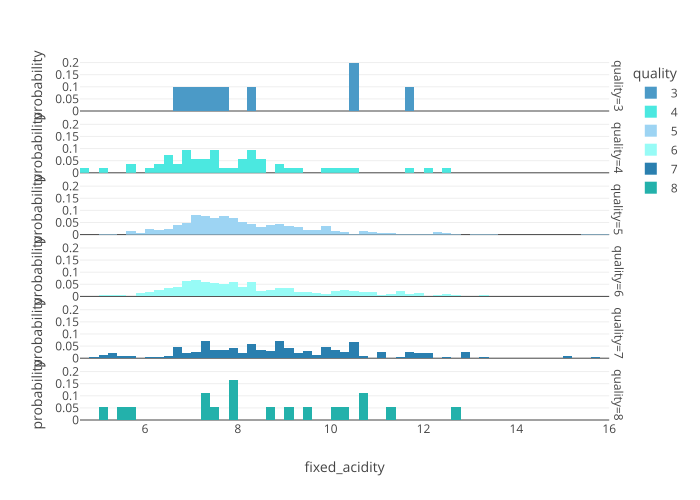

In [288]:
cat_order = {
    'quality': [3, 4, 5, 6, 7, 8]
}

def display_distribution(f):
    fig_jedha = px.histogram(dataset, f, color = 'quality', facet_row = 'quality', histnorm = 'probability', 
                       category_orders = cat_order)
    fig_jedha.show()
    
display_distribution('fixed_acidity')

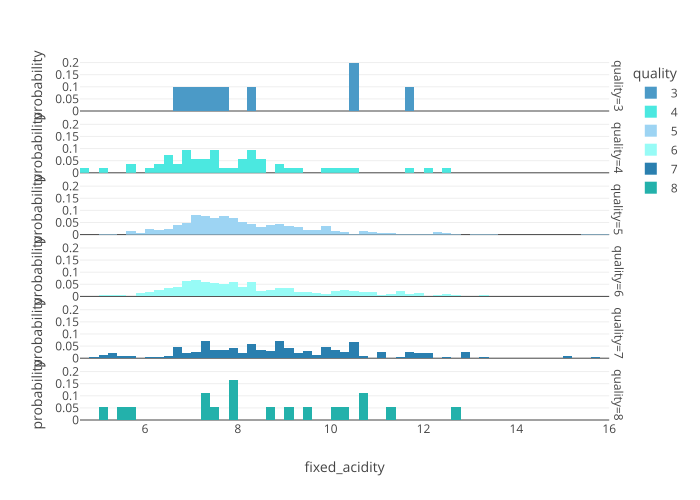

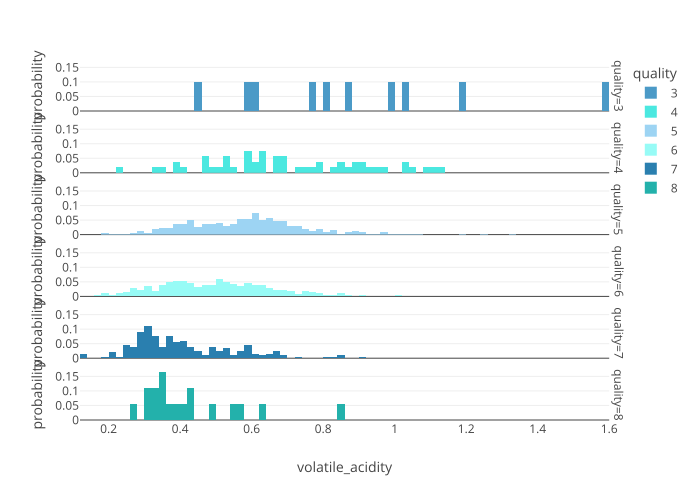

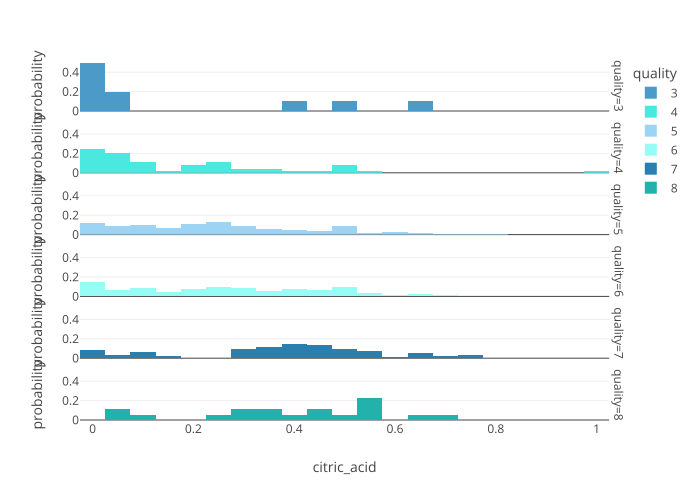

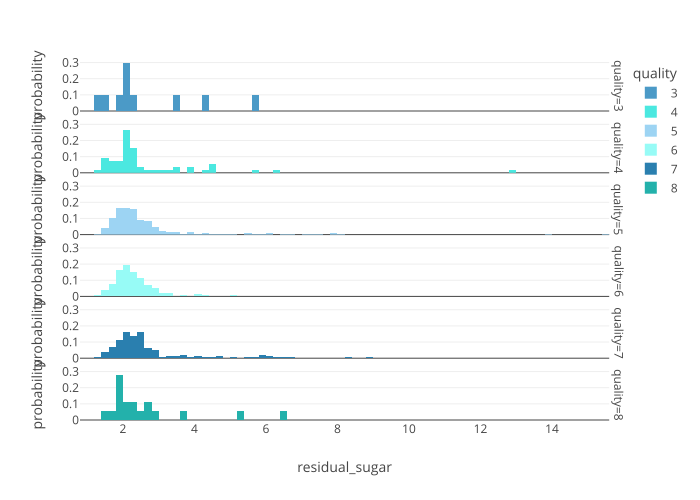

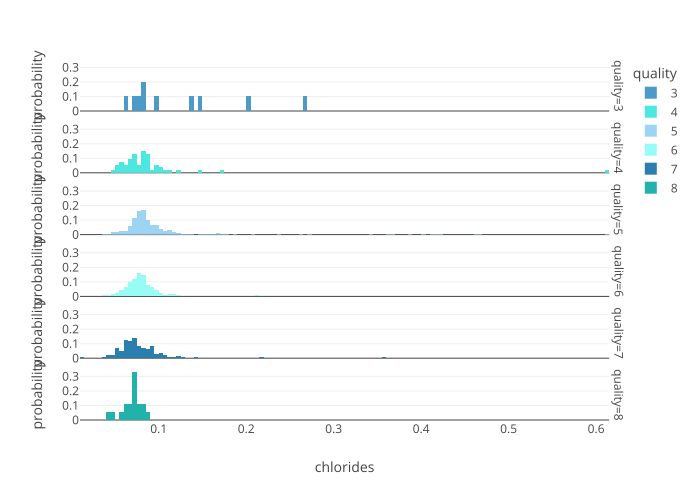

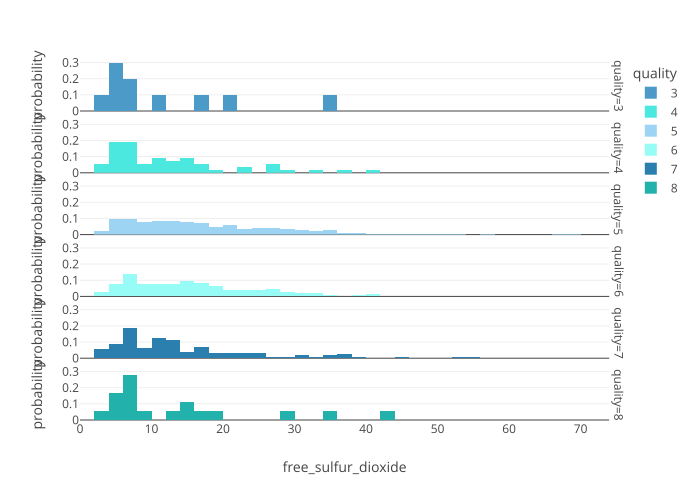

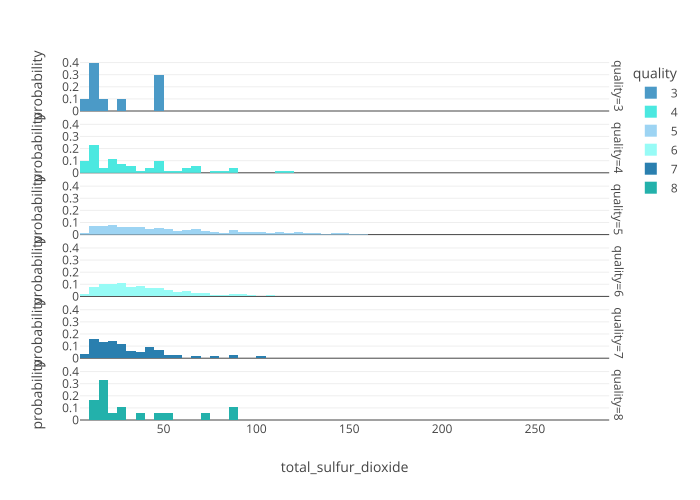

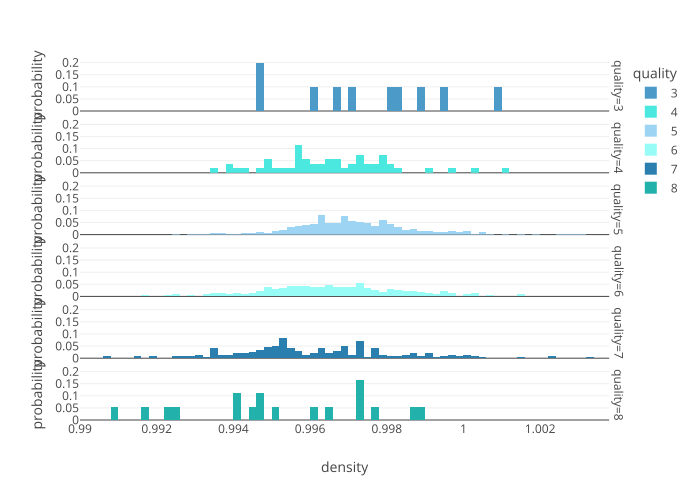

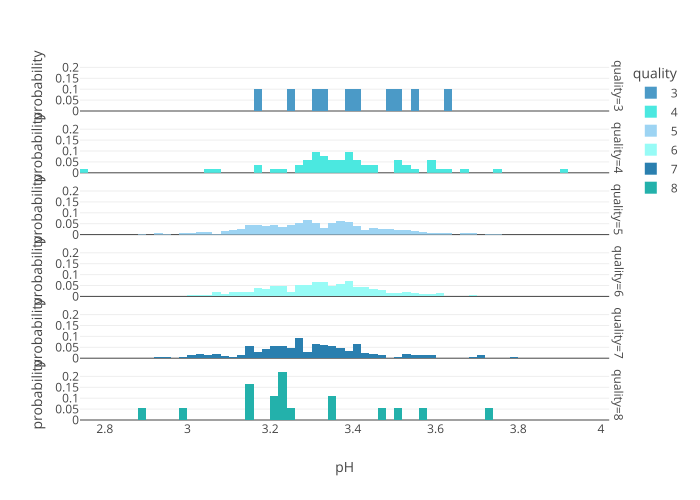

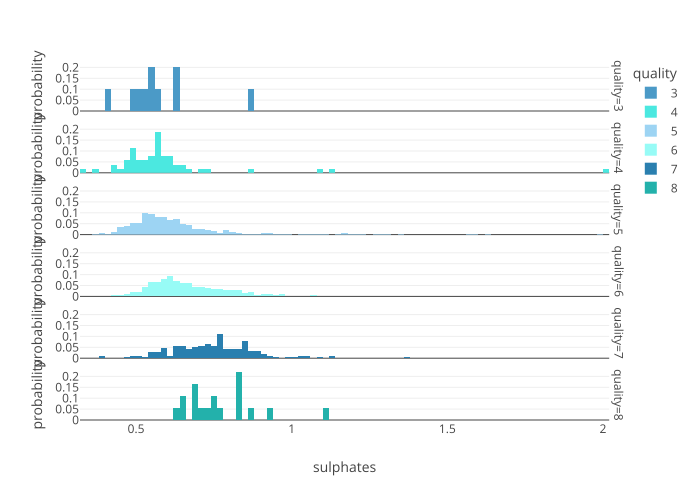

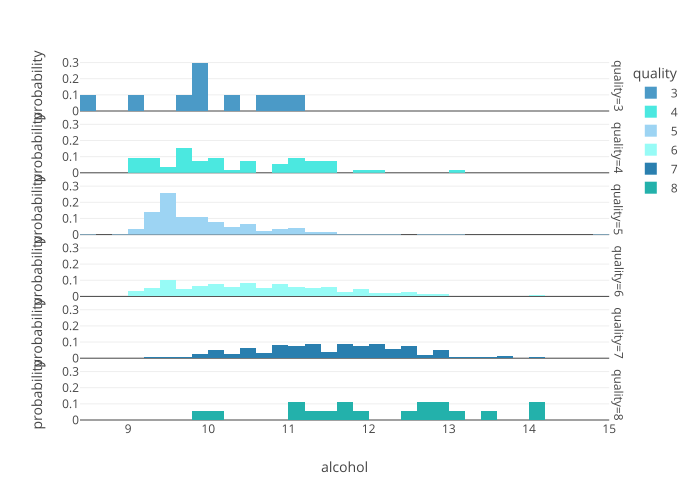

In [289]:
# Univariate analysis
num_features = dataset.columns.drop("quality")
cat_order = {
    'quality': [3, 4, 5, 6, 7, 8]
}
for f in num_features:
    fig = px.histogram(dataset, f, color="quality", facet_row="quality", histnorm="probability", category_orders=cat_order)
    fig.show()

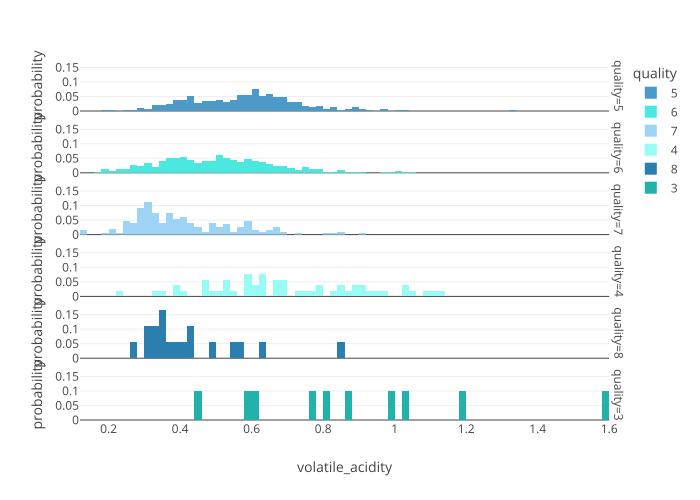

In [290]:
fig2 = px.histogram(dataset, "volatile_acidity", color="quality", facet_row="quality", histnorm="probability")
fig2.show()

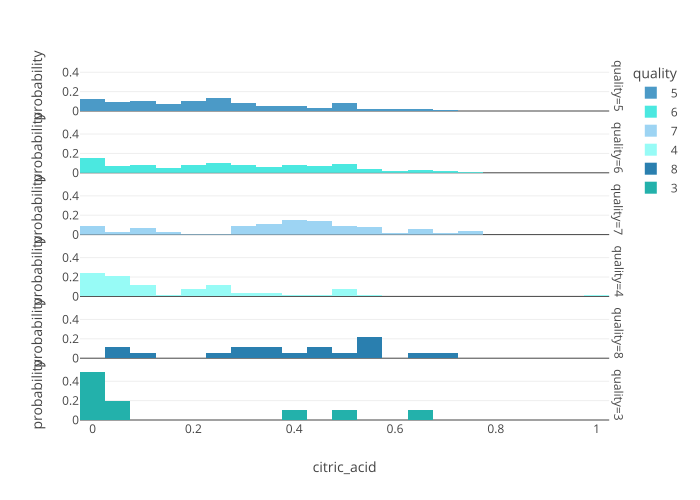

In [291]:
fig3 = px.histogram(dataset, "citric_acid", color="quality", facet_row="quality", histnorm="probability")
fig3.show()

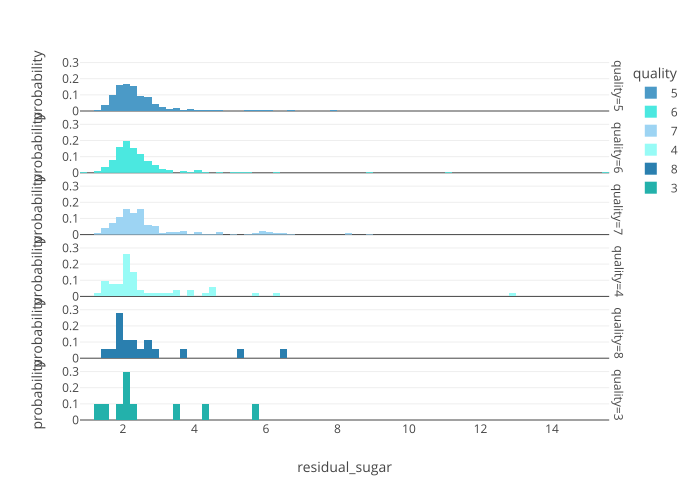

In [292]:
fig4 = px.histogram(dataset, "residual_sugar", color="quality", facet_row="quality", histnorm="probability")
fig4.show()

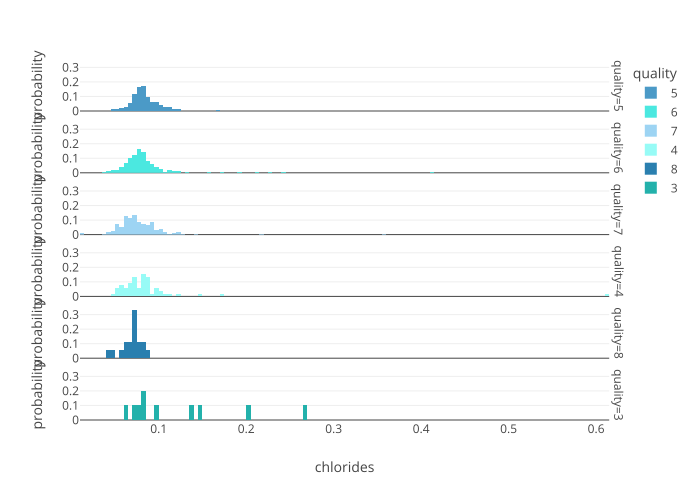

In [293]:
fig5 = px.histogram(dataset, "chlorides", color="quality", facet_row="quality", histnorm="probability")
fig5.show()

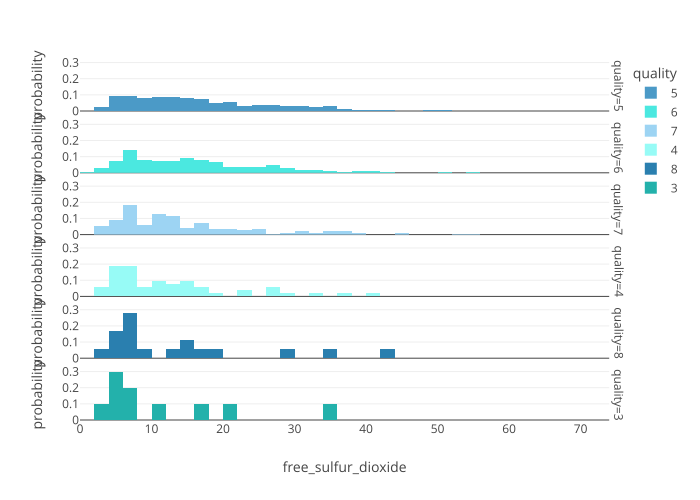

In [294]:
fig6 = px.histogram(dataset, "free_sulfur_dioxide", color="quality", facet_row="quality", histnorm="probability")
fig6.show()

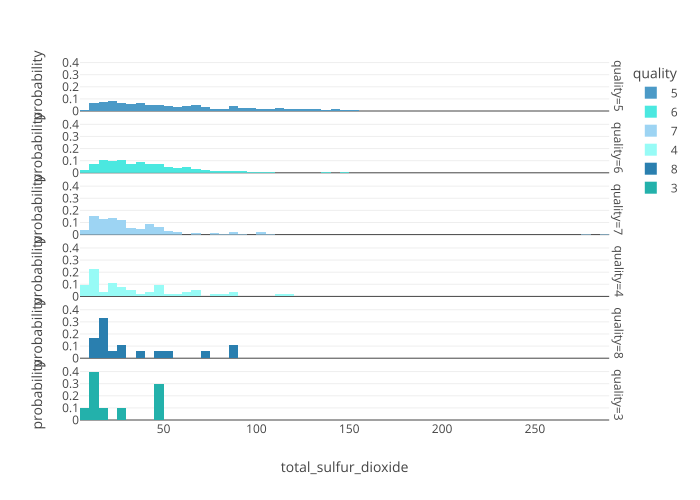

In [295]:
fig7 = px.histogram(dataset, "total_sulfur_dioxide", color="quality", facet_row="quality", histnorm="probability")
fig7.show()

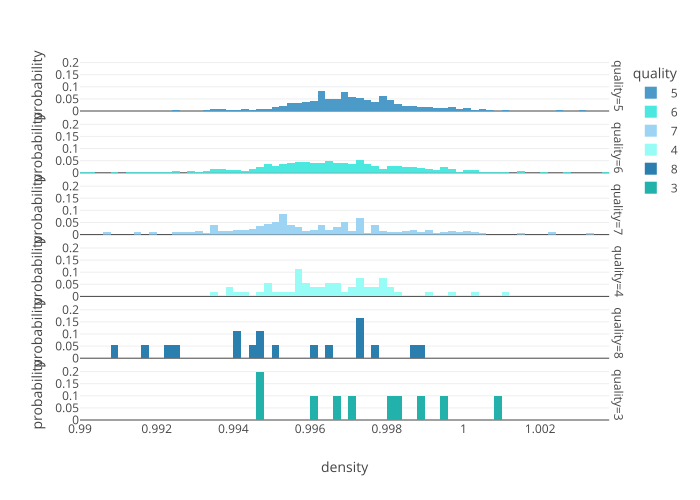

In [296]:
fig8 = px.histogram(dataset, "density", color="quality", facet_row="quality", histnorm="probability")
fig8.show()

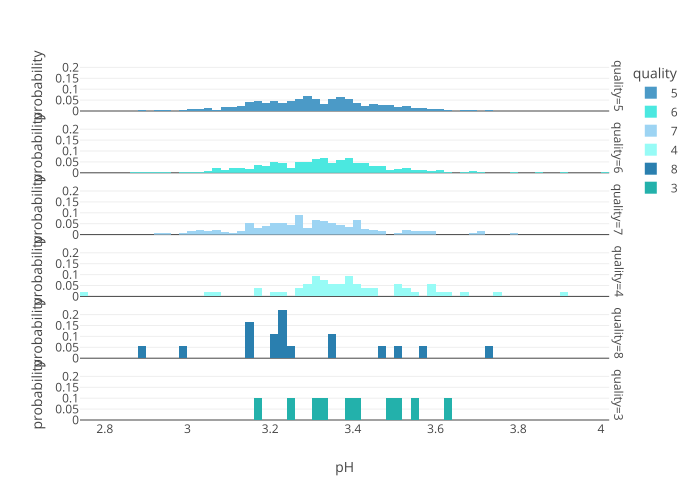

In [297]:
fig9 = px.histogram(dataset, "pH", color="quality", facet_row="quality", histnorm="probability")
fig9.show()

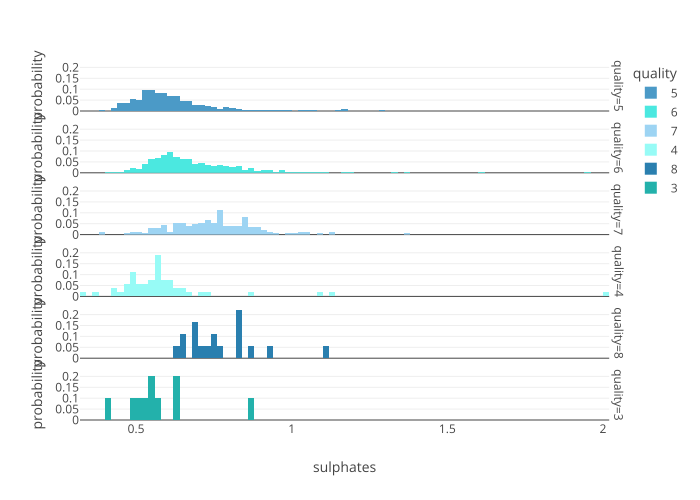

In [298]:
fig10 = px.histogram(dataset, "sulphates", color="quality", facet_row="quality", histnorm="probability")
fig10.show()

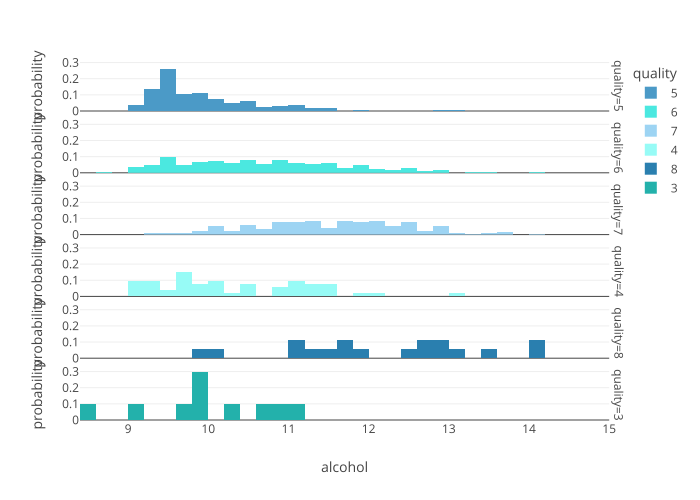

In [299]:
fig11 = px.histogram(dataset, "alcohol", color="quality", facet_row="quality", histnorm="probability")
fig11.show()

5. Is the target variable uniformely distributed across all possible values? Is it possible to use logistic regression to predict the values of quality? How?

In [300]:
dataset["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

6. Create a baseline model (univariate logistic regression). Take one feature that seems to be a good predictor for the wine quality. What's the model accuracy on train/test sets?

Hint: if some preprocessings are necessary, apply it to X_train/X_test

In [301]:
# Separate target variable Y from features X
print("Separating labels from features...")
Y = dataset.iloc[:, -1]
Y = np.array(Y).ravel()
X = dataset.iloc[:, -2:-1]
print('...Done.')
print(Y[0:5])
print()
print(X.head())

Separating labels from features...
...Done.
[5 5 5 6 5]

   alcohol
0      9.4
1      9.8
2      9.8
3      9.8
4      9.4


In [302]:
# Divide dataset train set & test set
print("Dividing into train and test sets")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")

Dividing into train and test sets
...Done.


In [303]:
# Prerpocessing
print("Preprocessing X_train...")
print(X_train.head())
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
print("...Done.")
print(X_train[0:5])
print()

print("Preprocessing X_test...")
print(X_test.head())
X_test = sc.transform(X_test)
print("...Done.")
print(X_test[0:5])

Preprocessing X_train...
      alcohol
642       9.4
679       9.6
473      10.6
390      12.9
1096     10.8
...Done.
[[-0.95579434]
 [-0.76727388]
 [ 0.17532846]
 [ 2.34331382]
 [ 0.36384892]]

Preprocessing X_test...
      alcohol
1109     10.8
1032      9.6
1002     11.7
487      10.0
979      10.4
...Done.
[[ 0.36384892]
 [-0.76727388]
 [ 1.21219102]
 [-0.39023294]
 [-0.01319201]]


In [304]:
print("Train model ...")
classifier = LogisticRegression()
classifier.fit(X_train, Y_train)
print("...Done.")

Train model ...
...Done.


In [305]:
print("accuracy score on training set : ", classifier.score(X_train, Y_train))
print("accuracy score on test set : ", classifier.score(X_test, Y_test))

accuracy score on training set :  0.5465207193119624
accuracy score on test set :  0.578125


7. Use cross-validation with cv=10 to get a better feel of the model's average performance on this dataset.

In [306]:
# Cross validation scores
scores = cross_val_score(classifier, X_train, Y_train, cv=10)
print("The cross-validated accuracy is : ", scores.mean())
print("The standard deviation is : ", scores.std())

The cross-validated accuracy is :  0.5410617618110236
The standard deviation is :  0.027051325500817094


c:\Users\briic\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning:

The least populated class in y has only 8 members, which is less than n_splits=10.



8. What would be the test accuracy for a "dummy" model that would always predict the most frequent class? Is the baseline model interesting?

In [307]:
Y_test_pred_dummy[0:5]

[5, 5, 5, 5, 5]

In [308]:
#From question 5., we know that the most frequent class is quality = 5. 
# Let's create a list Y_pred_dummy in which every element is equal to 5, and compute the accuracy:
Y_test_pred_dummy = [5]*len(Y_test)
print("dummy accuracy on test set : ", accuracy_score(Y_test, Y_test_pred_dummy))

dummy accuracy on test set :  0.421875


9. Train a multivariate model by including all the features and compute its accuracy on train/test.

Hint1: Do the explanatory variables need imputation, encoding or normalization? If so proceed to the necessary transformations. Why is normalization important when using logistic regression?

Hint2: If you get a "convergence warning" while training the model, you might want to increase the value of the argument "max_iter" in the LogisticRegression 🤓

In [309]:
# Multivariate model.
print("Number of rows: ", len(dataset))
print()
print("Display of dataset:")
print(dataset.head())
print()
print("Basics statistics:")
print(dataset.describe(include="all"))
print()
print("Percentage of missing values:")
print(100*dataset.isnull().sum() / len(dataset))

Number of rows:  1599

Display of dataset:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  

In [310]:
# Separating labels from features
print("Sepatating labels from features...")
Y = dataset.iloc[:, -1]
X = dataset.iloc[:, :-1]
print("...Done.")
print()
print(Y.head())
print()
print(X.head())

Sepatating labels from features...
...Done.

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.997

In [311]:
# Divide train test ant test set
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems autrement déséquilibre non maintenu dans les classes.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2, random_state=0, stratify= Y)
print("...Done.")

Dividing into train and test sets...
...Done.


In [312]:
# Preprocessing
print("Performing preprocessings on train set...")
print(X_train.head())
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
print("...Done.")
print(X_train[0:5])
print()

print("Performing preprocessings on test set...")
print(X_test.head())
X_test = sc.transform(X_test)
print("...Done.")
print(X_test[0:5])

Performing preprocessings on train set...
      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
299             6.9             0.670         0.06             2.1      0.080   
364            12.8             0.615         0.66             5.8      0.083   
1216            7.9             0.570         0.31             2.0      0.079   
401             7.7             0.260         0.30             1.7      0.059   
1481            8.2             0.280         0.60             3.0      0.104   

      free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
299                   8.0                  33.0  0.99845  3.68       0.71   
364                   7.0                  42.0  1.00220  3.07       0.73   
1216                 10.0                  79.0  0.99677  3.29       0.69   
401                  20.0                  38.0  0.99490  3.29       0.47   
1481                 10.0                  22.0  0.99828  3.39       0.68   

      al

In [313]:
# training model
print("Train model...")
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [314]:
print("accuracy score on training set : ", classifier.score(X_train, Y_train))
print("accuracy score on test set:", classifier.score(X_test, Y_test))

accuracy score on training set :  0.6300940438871473
accuracy score on test set: 0.58359375


10. Is this model significantly better than the baseline?

In [315]:
Y.shape

(1599,)

In [316]:
# Cross validation
scores = cross_val_score(classifier, X_train, Y_train, cv=10)

print("The cross_validated accuracy is :", scores.mean())
print("The standard deviation is :", scores.std())

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning:

The least populated class in y has only 2 members, which is less than n_splits=10.



The cross_validated accuracy is : 0.5805443548387097
The standard deviation is : 0.08702750054624539


11. Extract the model's predictions on train/test sets. Use these values to plot the confusion matrices.

In [317]:
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred[0:5])
print()
print("Prediction on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred[0:5])

Predictions on training set...
...Done.
[5 7 5 6 6]

Prediction on test set...
...Done.
[6 6 5 5 5]


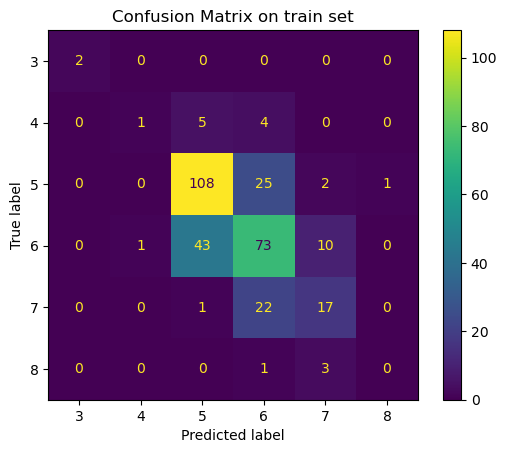

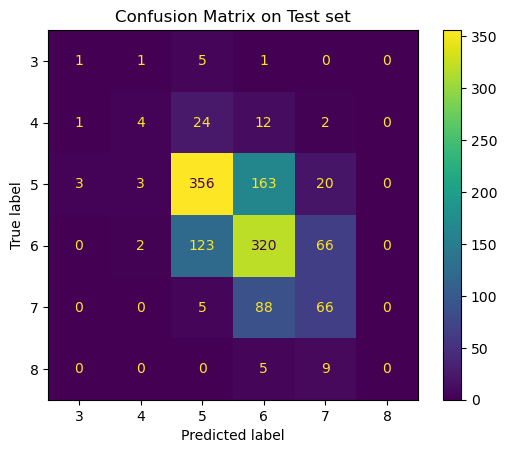

In [318]:
# Visualize confusion matrices
_, ax = plt.subplots() # get subplot from matplolib
ax.set(title="Confusion Matrix on train set") # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, ax=ax) # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()
ax.set(title="Confusion Matrix on Test set")
ConfusionMatrixDisplay.from_estimator(classifier, X_test, Y_test, ax=ax)
plt.show()

12. Analyze the model's coefficients. Can you deduce easily what are the most important features to predict the wine quality?

In [319]:
print("Coefficients of the Logistic regression model:")
coeff = classifier.coef_
coeff

Coefficients of the Logistic regression model:


array([[-1.61565596e-01,  1.15676421e+00, -3.81871866e-01,
         8.61217992e-01, -1.93403648e-04, -7.16996208e-01,
        -4.84224371e-01,  3.70276313e-01,  3.70401750e-01,
        -3.30568489e-01, -3.77236028e-02],
       [-1.55462557e-01,  3.20241856e-01, -1.58569747e-01,
         8.21144474e-02, -2.80351916e-01, -2.76352710e-01,
        -8.17294953e-01,  3.35943453e-02,  1.48396547e-01,
        -1.01453202e+00, -2.70700166e-01],
       [-3.44427368e-01,  5.09137933e-03,  4.52281374e-01,
        -3.70544960e-01,  5.37634813e-01,  1.10250851e-01,
         7.65645034e-01,  1.46862000e-01,  2.93555902e-01,
        -3.15923575e-01, -1.13560005e+00],
       [-2.00396345e-01, -5.31233892e-01, -5.84170162e-02,
        -4.99425179e-01,  4.50089881e-01,  3.01047513e-01,
         3.24601125e-01,  2.60329806e-01, -1.51742708e-01,
        -8.45142845e-03, -2.28409283e-02],
       [ 6.40505917e-01, -4.71876559e-01, -1.07662830e-01,
         2.52693148e-01, -1.02421196e-01,  1.72870903e-01,
  

In [320]:
Y.shape

(1599,)

In [321]:
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [322]:
#autre méthode
# Create a pandas DataFrame with the model's coefficients
# coefs = pd.DataFrame(index = X.columns, data = classifier.coef_.transpose(), columns=[3, 4, 5, 6, 7, 8])
coeff_pd = pd.DataFrame(
    coeff.T,
    index= X.columns,
    columns= classifier.classes_
)
print(coeff_pd)

                             3         4         5         6         7  \
fixed_acidity        -0.161566 -0.155463 -0.344427 -0.200396  0.640506   
volatile_acidity      1.156764  0.320242  0.005091 -0.531234 -0.471877   
citric_acid          -0.381872 -0.158570  0.452281 -0.058417 -0.107663   
residual_sugar        0.861218  0.082114 -0.370545 -0.499425  0.252693   
chlorides            -0.000193 -0.280352  0.537635  0.450090 -0.102421   
free_sulfur_dioxide  -0.716996 -0.276353  0.110251  0.301048  0.172871   
total_sulfur_dioxide -0.484224 -0.817295  0.765645  0.324601  0.343377   
density               0.370276  0.033594  0.146862  0.260330 -0.350787   
pH                    0.370402  0.148397  0.293556 -0.151743 -0.391747   
sulphates            -0.330568 -1.014532 -0.315924 -0.008451  0.637953   
alcohol              -0.037724 -0.270700 -1.135600 -0.022841  0.792837   

                             8  
fixed_acidity         0.221346  
volatile_acidity     -0.478987  
citric_acid 

13. Use Chi2 test in order to analyse the importance of each variable in your dataset. You may find more information on this test following this link : [scikitlearn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html)

In [323]:
from sklearn.feature_selection import chi2

chi2_stats, p_values = chi2(X, Y)

print(chi2_stats)
print()
print(p_values)

[1.12606524e+01 1.55802891e+01 1.30256651e+01 4.12329474e+00
 7.52425579e-01 1.61936036e+02 2.75555798e+03 2.30432045e-04
 1.54654736e-01 4.55848775e+00 4.64298922e+01]

[4.64500416e-02 8.15035154e-03 2.31394417e-02 5.31804675e-01
 9.79968040e-01 3.82728810e-33 0.00000000e+00 1.00000000e+00
 9.99526491e-01 4.72096321e-01 7.42403757e-09]


14. Put these values into a DataFrame for more readability.

In [324]:
new_pd = pd.DataFrame({
    "feature": X.columns,
    "Chi2": chi2_stats,
    "p_values": p_values
})
new_pd.sort_values("Chi2")

# autre méthode
# feature_ranking = pd.DataFrame(columns=X.columns, data=feature_importance, 
#                                index=["Chi2 Score", "P-value"]).transpose().sort_values("Chi2 Score")
# feature_ranking = feature_ranking.reset_index().rename({'index': 'feature'}, axis = 1)
# feature_ranking

,feature,Chi2,p_values
7,density,0.000230,1.000000e+00
8,pH,0.154655,9.995265e-01
4,chlorides,0.752426,9.799680e-01
3,residual_sugar,4.123295,5.318047e-01
9,sulphates,4.558488,4.720963e-01
0,fixed_acidity,11.260652,4.645004e-02
2,citric_acid,13.025665,2.313944e-02
1,volatile_acidity,15.580289,8.150352e-03
10,alcohol,46.429892,7.424038e-09
5,free_sulfur_dioxide,161.936036,3.827288e-33


15. Create a barchart visualization, what can you conclude ?

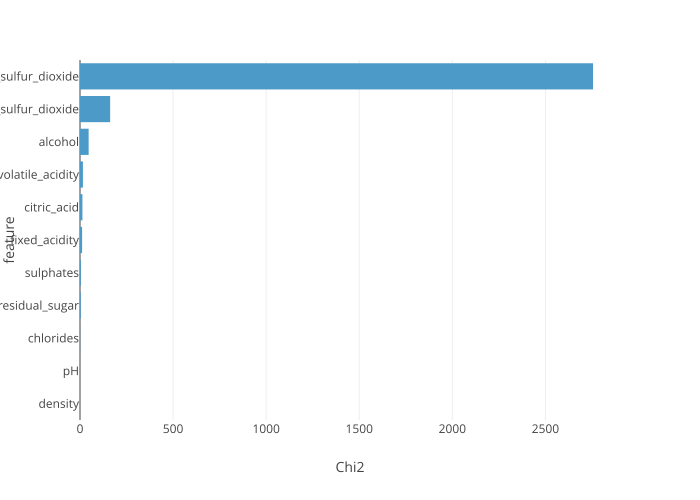

In [325]:
fig12 = px.bar(new_pd, x="Chi2", y="feature")
fig12.update_yaxes(categoryorder="total ascending")
fig12.show()

16. Try fitting the same model using the argument class_weight="balanced", what are the consequences on all the aspects of the performances studied before ?

In [326]:
classifier = LogisticRegression(class_weight="balanced") # takes into account the different classes' proportions
classifier.fit(X_train, Y_train)
print("accuracy score on training set : ", classifier.score(X_train, Y_train))
print("accuracy score on test set:", classifier.score(X_test, Y_test))

accuracy score on training set :  0.54858934169279
accuracy score on test set: 0.4578125


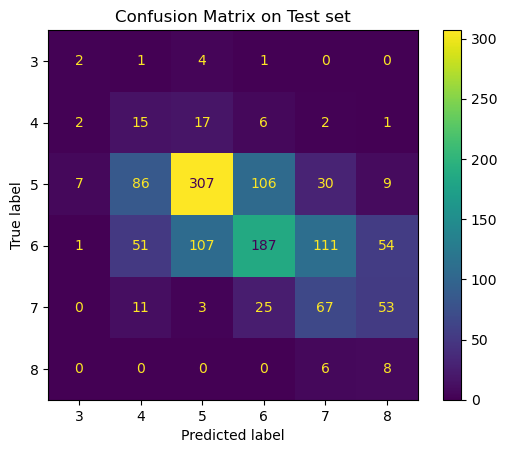

In [327]:
_, ax = plt.subplots()
ax.set(title="Confusion Matrix on Test set")
ConfusionMatrixDisplay.from_estimator(classifier, X_test, Y_test, ax=ax)
plt.show()

# The model's performances have been deteriorated, but now all the classes are treated with equal importances, 
# which means that the model tries to make good predictions even for rare classes

21. As an extra question for which no fixed solution will be proposed, attempt to improve the score using feature engineering (create new variables using common functions, combining variables together in a non-linear way etc...)